In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data = {i: pd.read_csv(f"alpha0{i}/results/evaluation.csv") for i in [1, 2, 3, 4, 5, 6, 7, 8, 9]}

In [3]:
baseline = data[1].mean()['Stage 0']

/var/folders/wn/3cxs5bc91hsbl4gwt8j95d0h0000gp/T/ipykernel_3351/4132203027.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[0].set_xticklabels(axarr[0].get_xticklabels(), rotation=90)


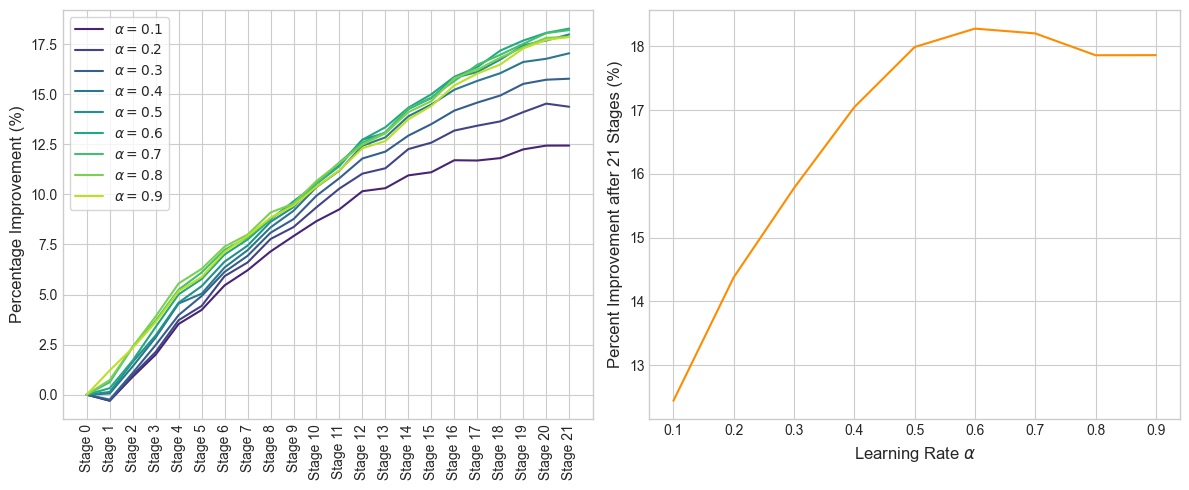

In [4]:
fig, axarr = plt.subplots(1, 2, figsize=(12, 5))
cmap = mpl.colormaps['viridis']
for i in range(1, 10):
    axarr[0].plot((1 - (data[i].mean() / baseline)) * 100, c=cmap(i/10), label=fr"$\alpha = 0.{i}$")
axarr[0].set_ylabel("Percentage Improvement (%)", fontsize=12)
axarr[0].legend(frameon=True)
axarr[0].set_xticklabels(axarr[0].get_xticklabels(), rotation=90)

axarr[1].plot(
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    [((data[i].mean()['Stage 0'] - data[i].mean()['Stage 21']) / baseline) * 100 for i in [1, 2, 3, 4, 5, 6, 7, 8, 9]],
    c='darkorange'
)
axarr[1].set_xlabel(r"Learning Rate $\alpha$", fontsize=12)
axarr[1].set_ylabel("Percent Improvement after 21 Stages (%)", fontsize=12)
plt.tight_layout()
fig.savefig("vary_alpha.pdf")